# Laporan Proyek Machine Learning - William

**Proyek Pertama: Predictive Analytics — Klasifikasi Risiko Gagal Bayar Kartu Kredit**

Notebook ini mendokumentasikan alur proyek machine learning secara utuh, mulai dari
*problem domain*, *business understanding*, *data understanding*, *data preparation*,
*modeling*, hingga *evaluation*. Setiap tahapan dijelaskan melalui text cell dan
diimplementasikan pada code cell di bawahnya, dengan urutan yang sama seperti pada
laporan Markdown pendamping (`Laporan Proyek Machine Learning - William.md`).

## Domain Proyek

### Latar Belakang

Industri kartu kredit bertumpu pada satu asumsi dasar: sebagian pemegang kartu akan gagal
memenuhi kewajiban pembayarannya. Ketika kegagalan bayar (*default*) terjadi, kerugian tidak
hanya dialami penerbit kartu, tetapi juga merambat ke sistem keuangan yang lebih luas. Bank
Indonesia mencatat bahwa kredit konsumsi—termasuk kartu kredit—merupakan salah satu segmen
yang paling sensitif terhadap perubahan kualitas daya bayar rumah tangga, sehingga
pengelolaan risikonya menjadi prioritas pengawasan.

Persoalannya, penilaian kelayakan kredit secara konvensional masih banyak mengandalkan
penilaian manual dan indikator keuangan yang terbatas pada satu titik waktu. Pendekatan ini
memiliki dua kelemahan mendasar. Pertama, ia tidak mampu menangkap pola perilaku pembayaran
yang bersifat historis dan multidimensi. Kedua, ia tidak dapat diskalakan untuk memproses
ribuan aplikasi dalam waktu singkat. Padahal data historis nasabah—riwayat tagihan, riwayat
pembayaran, dan keterlambatan bulanan—sebenarnya tersimpan dan dapat dimanfaatkan.

*Machine learning* menawarkan solusi yang tepat untuk permasalahan ini. Algoritma klasifikasi
dapat mempelajari pola dari data historis nasabah dan menghasilkan model prediktif yang
mampu mengestimasi probabilitas gagal bayar seorang nasabah di periode berikutnya. Model
semacam ini memungkinkan institusi keuangan melakukan deteksi dini secara otomatis, konsisten,
dan terukur.

### Mengapa dan Bagaimana Masalah Ini Harus Diselesaikan

Masalah ini harus diselesaikan karena dampaknya bersifat langsung terhadap profitabilitas dan
stabilitas. Setiap nasabah yang gagal bayar merepresentasikan kerugian pokok ditambah biaya
penagihan, sementara nasabah yang sebenarnya layak tetapi ditolak berarti kehilangan potensi
pendapatan. Kedua jenis kesalahan ini memiliki biaya nyata, sehingga keputusan kredit harus
diambil berdasarkan estimasi risiko yang terkalibrasi, bukan intuisi.

Pendekatannya adalah dengan membangun model klasifikasi biner yang memprediksi status gagal
bayar bulan berikutnya berdasarkan data historis enam bulan terakhir. Model kemudian
dievaluasi menggunakan metrik yang sesuai dengan konteks data yang tidak seimbang
(*imbalanced*), sehingga keputusan yang diambil berbasis angka yang dapat dipertanggungjawabkan.

### Referensi

1. Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the
   predictive accuracy of probability of default of credit card clients. *Expert Systems with
   Applications*, 36(2), 2473–2480.
2. Lessmann, S., Baesens, B., Seow, H. V., & Thomas, L. C. (2015). Benchmarking state-of-the-art
   classification algorithms for credit scoring: An update of research. *European Journal of
   Operational Research*, 247(1), 124–136.
3. Barboza, F., Kimura, H., & Altman, E. (2017). Machine learning models and bankruptcy
   prediction. *Expert Systems with Applications*, 83, 405–417.
4. Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
5. Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine.
   *Annals of Statistics*, 29(5), 1189–1232.

## Business Understanding

### Problem Statements

Berdasarkan latar belakang di atas, permasalahan yang akan diselesaikan dirumuskan sebagai berikut.

- **Pernyataan Masalah 1:** Faktor-faktor apa saja dari data historis nasabah—meliputi limit
  kredit, demografi, riwayat tagihan, dan riwayat pembayaran—yang paling berpengaruh terhadap
  terjadinya gagal bayar pada bulan berikutnya?
- **Pernyataan Masalah 2:** Bagaimana membangun model machine learning yang mampu memprediksi
  probabilitas seorang nasabah akan gagal bayar pada bulan berikutnya, dengan tingkat akurasi
  yang dapat diandalkan?
- **Pernyataan Masalah 3:** Algoritma mana yang memberikan performa terbaik dalam menyelesaikan
  permasalahan klasifikasi gagal bayar ini, dan mengapa algoritma tersebut dipilih?

### Goals

Tujuan yang ingin dicapai dari perumusan masalah di atas adalah sebagai berikut.

- **Jawaban Pernyataan Masalah 1:** Mengidentifikasi dan mengukur tingkat kepentingan
  (*feature importance*) setiap fitur terhadap target gagal bayar, sehingga faktor risiko
  dominan dapat diketahui secara kuantitatif.
- **Jawaban Pernyataan Masalah 2:** Menghasilkan model klasifikasi yang mampu memprediksi
  status gagal bayar nasabah dengan performa yang terukur melalui metrik evaluasi yang sesuai
  untuk data tidak seimbang.
- **Jawaban Pernyataan Masalah 3:** Membandingkan performa beberapa algoritma klasifikasi
  secara objektif, kemudian memilih satu model terbaik sebagai solusi akhir beserta alasan
  pemilihannya.

### Solution statements

Untuk mencapai goals di atas, diajukan tiga solusi yang masing-masing dapat diukur dengan metrik evaluasi:

1. **Logistic Regression sebagai baseline.** Model linear yang sederhana dan interpretable,
   digunakan sebagai titik acuan performa. Keberhasilannya diukur melalui *ROC-AUC* dan
   *F1-score* pada kelas minoritas.
2. **Random Forest Classifier.** Algoritma *ensemble* berbasis *bagging* yang mampu menangkap
   hubungan non-linear antar fitur dan relatif tahan terhadap *outlier*. Diukur dengan metrik
   yang sama agar dapat dibandingkan secara langsung dengan baseline.
3. **Gradient Boosting Classifier.** Algoritma *ensemble* berbasis *boosting* yang membangun
   model secara sekuensial untuk memperbaiki kesalahan model sebelumnya, umumnya memberikan
   performa tinggi pada data tabular. Diukur dengan metrik yang sama.

Ketiga solusi di atas kemudian ditingkatkan melalui **hyperparameter tuning** menggunakan
`GridSearchCV` dengan *stratified cross-validation*, sehingga perbaikan performa dapat
dibuktikan secara kuantitatif, bukan diasumsikan.

In [1]:
# Cell 1 — Import library dan konfigurasi global
# Backend non-interaktif: plt.show() harus tidak memblokir saat notebook dieksekusi headless.
%matplotlib inline

import io
import json
import ssl
import urllib.request
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
TARGET_RAW = "default payment next month"
print("Library berhasil dimuat. Random state:", RANDOM_STATE)

Library berhasil dimuat. Random state: 42


## Data Understanding

Dataset yang digunakan adalah **Default of Credit Card Clients Dataset** dari UCI Machine
Learning Repository. Dataset ini merekam data 30.000 nasabah kartu kredit di Taiwan pada
periode April–September 2005, mencakup informasi demografi, limit kredit, riwayat tagihan
enam bulan, dan riwayat pembayaran enam bulan.

- **Sumber data (tautan unduh):** https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
- **Jumlah sampel:** 30.000 baris (memenuhi syarat minimum 500 sampel)
- **Jumlah kolom:** 25 kolom — 23 fitur prediktor + 1 kolom `ID` + 1 kolom target
  (menjadi 29 fitur prediktor setelah `ID` dibuang dan fitur turunan ditambahkan)
- **Jenis data:** kuantitatif dan kategorikal terenkode numerik
- **Target:** `default payment next month` — 1 jika nasabah gagal bayar bulan berikutnya, 0 jika tidak

Dataset ini dipilih karena relevan dengan domain keuangan, berukuran besar, dan merupakan
dataset rujukan yang telah digunakan secara luas dalam literatur *credit scoring*.

In [2]:
# Cell 2 — Memuat dataset langsung dari sumber resmi UCI
DATA_URL = "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip"
LOCAL_CSV = "credit_default.csv"


def _ssl_context():
    """Konteks SSL dengan CA bundle dari certifi (macOS sering tanpa CA bawaan)."""
    try:
        import certifi

        return ssl.create_default_context(cafile=certifi.where())
    except ImportError:
        return ssl.create_default_context()


def load_dataset():
    """Unduh dataset asli dari UCI; fallback ke salinan lokal bila unduhan gagal."""
    try:
        request = urllib.request.Request(DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request, timeout=90, context=_ssl_context()) as resp:
            archive = zipfile.ZipFile(io.BytesIO(resp.read()))
        member = [n for n in archive.namelist() if n.lower().endswith(".xls")][0]
        return pd.read_excel(io.BytesIO(archive.read(member)), header=1)
    except Exception as exc:  # noqa: BLE001 - fallback disengaja untuk lingkungan offline
        print(f"[fallback] unduhan gagal ({type(exc).__name__}: {exc}); membaca salinan lokal.")
        # Cari salinan lokal di direktori kerja atau satu tingkat di atasnya.
        for base in (Path.cwd(), *Path.cwd().parents[:2]):
            candidate = base / LOCAL_CSV
            if candidate.exists():
                return pd.read_csv(candidate)
        raise FileNotFoundError(f"{LOCAL_CSV} tidak ditemukan untuk fallback offline")


df = load_dataset()
df.columns = [str(c).strip() for c in df.columns]

# Pemeriksaan kewajaran data sebelum analisis dilanjutkan
assert df.shape[0] == 30000, f"jumlah baris tak terduga: {df.shape[0]}"
assert TARGET_RAW in df.columns, "kolom target tidak ditemukan"
assert df[TARGET_RAW].nunique() == 2, "target harus biner"

print(f"Ukuran dataset : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Kolom target   : {TARGET_RAW}")
df.head()

Ukuran dataset : 30,000 baris x 25 kolom
Kolom target   : default payment next month


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# Cell 3 — Gambaran umum kondisi data
print("=== Tipe data ===")
print(df.dtypes.value_counts().to_string())

print("\n=== Nilai hilang ===")
print(f"Total nilai hilang : {int(df.isna().sum().sum())}")
print(f"Baris duplikat     : {int(df.duplicated().sum())}")

print("\n=== Statistik deskriptif (kolom numerik utama) ===")
df[["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]].describe().round(2)

=== Tipe data ===
int64    25

=== Nilai hilang ===
Total nilai hilang : 0
Baris duplikat     : 0

=== Statistik deskriptif (kolom numerik utama) ===


,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,30000.00,30000.00,30000.00,30000.00
mean,167484.32,35.49,51223.33,5663.58
std,129747.66,9.22,73635.86,16563.28
min,10000.00,21.00,-165580.00,0.00
25%,50000.00,28.00,3558.75,1000.00
50%,140000.00,34.00,22381.50,2100.00
75%,240000.00,41.00,67091.00,5006.00
max,1000000.00,79.00,964511.00,873552.00


=== Distribusi target ===
Lancar (0)        : 23,364 (77.88%)
Gagal bayar (1)   :  6,636 (22.12%)
Rasio ketidakseimbangan: 1 : 3.52


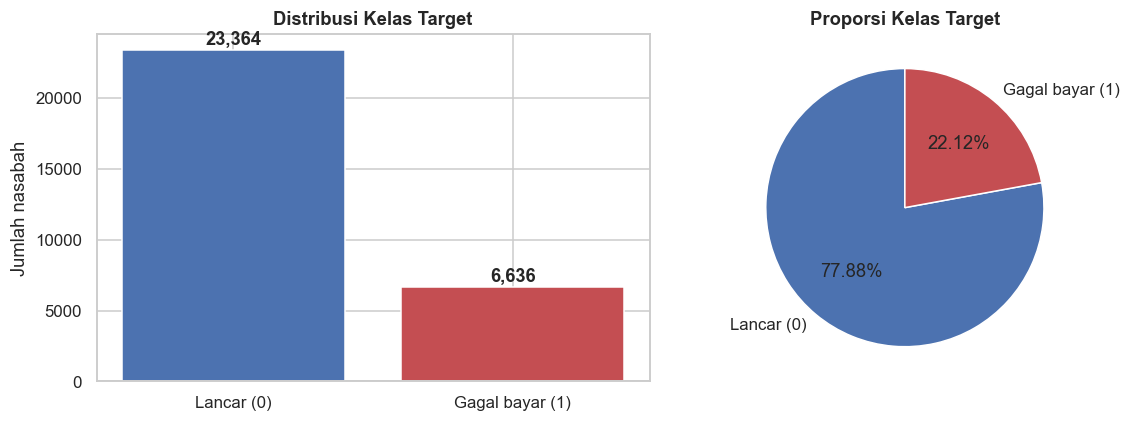

In [4]:
# Cell 4 — Distribusi kelas target (kondisi ketidakseimbangan)
target_counts = df[TARGET_RAW].value_counts().sort_index()
target_pct = df[TARGET_RAW].value_counts(normalize=True).sort_index() * 100

print("=== Distribusi target ===")
for label in target_counts.index:
    name = "Gagal bayar (1)" if label == 1 else "Lancar (0)"
    print(f"{name:18s}: {target_counts[label]:>6,} ({target_pct[label]:.2f}%)")
print(f"Rasio ketidakseimbangan: 1 : {target_counts[0] / target_counts[1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["Lancar (0)", "Gagal bayar (1)"], target_counts.values,
            color=["#4C72B0", "#C44E52"], edgecolor="white")
axes[0].set_title("Distribusi Kelas Target")
axes[0].set_ylabel("Jumlah nasabah")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 400, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(target_counts.values, labels=["Lancar (0)", "Gagal bayar (1)"],
            autopct="%1.2f%%", colors=["#4C72B0", "#C44E52"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporsi Kelas Target")
plt.tight_layout()
plt.show()

### Variabel-variabel pada Default of Credit Card Clients dataset adalah sebagai berikut:

| Variabel | Tipe | Keterangan |
| :--- | :--- | :--- |
| `ID` | int | Identitas unik nasabah. Tidak digunakan sebagai fitur karena tidak memiliki daya prediksi. |
| `LIMIT_BAL` | float | Jumlah limit kredit yang diberikan, dalam Dolar Taiwan Baru (NT$). Mencakup limit kredit konsumsi dan kredit keluarga. |
| `SEX` | kategori | Jenis kelamin: 1 = laki-laki, 2 = perempuan. |
| `EDUCATION` | kategori | Tingkat pendidikan: 1 = pascasarjana, 2 = universitas, 3 = SMA, 4 = lainnya. |
| `MARRIAGE` | kategori | Status pernikahan: 1 = menikah, 2 = lajang, 3 = lainnya. |
| `AGE` | int | Usia nasabah dalam tahun. |
| `PAY_0` | ordinal | Status pembayaran pada September 2005: -2 = tidak ada konsumsi, -1 = bayar penuh, 0 = penggunaan kredit berputar, 1–9 = jumlah bulan keterlambatan. |
| `PAY_2` | ordinal | Status pembayaran pada Agustus 2005 (skala sama dengan `PAY_0`). |
| `PAY_3` | ordinal | Status pembayaran pada Juli 2005 (skala sama dengan `PAY_0`). |
| `PAY_4` | ordinal | Status pembayaran pada Juni 2005 (skala sama dengan `PAY_0`). |
| `PAY_5` | ordinal | Status pembayaran pada Mei 2005 (skala sama dengan `PAY_0`). |
| `PAY_6` | ordinal | Status pembayaran pada April 2005 (skala sama dengan `PAY_0`). |
| `BILL_AMT1` | float | Jumlah tagihan September 2005 (NT$). |
| `BILL_AMT2` | float | Jumlah tagihan Agustus 2005 (NT$). |
| `BILL_AMT3` | float | Jumlah tagihan Juli 2005 (NT$). |
| `BILL_AMT4` | float | Jumlah tagihan Juni 2005 (NT$). |
| `BILL_AMT5` | float | Jumlah tagihan Mei 2005 (NT$). |
| `BILL_AMT6` | float | Jumlah tagihan April 2005 (NT$). |
| `PAY_AMT1` | float | Jumlah pembayaran September 2005 (NT$). |
| `PAY_AMT2` | float | Jumlah pembayaran Agustus 2005 (NT$). |
| `PAY_AMT3` | float | Jumlah pembayaran Juli 2005 (NT$). |
| `PAY_AMT4` | float | Jumlah pembayaran Juni 2005 (NT$). |
| `PAY_AMT5` | float | Jumlah pembayaran Mei 2005 (NT$). |
| `PAY_AMT6` | float | Jumlah pembayaran April 2005 (NT$). |
| `default payment next month` | target | Variabel target: 1 = gagal bayar bulan berikutnya, 0 = tidak gagal bayar. |

**Catatan penting mengenai `PAY_0`:** pada dataset asli UCI, kolom ini sebenarnya merepresentasikan
status pembayaran bulan September 2005 (yaitu bulan terakhir dalam jendela observasi) dan
semestinya diberi nama `PAY_1`. Penamaan `PAY_0` dipertahankan agar konsisten dengan sumber
asli, namun perlu dipahami bahwa kolom ini adalah **status pembayaran paling mutakhir** dan
karena itu sangat prediktif.

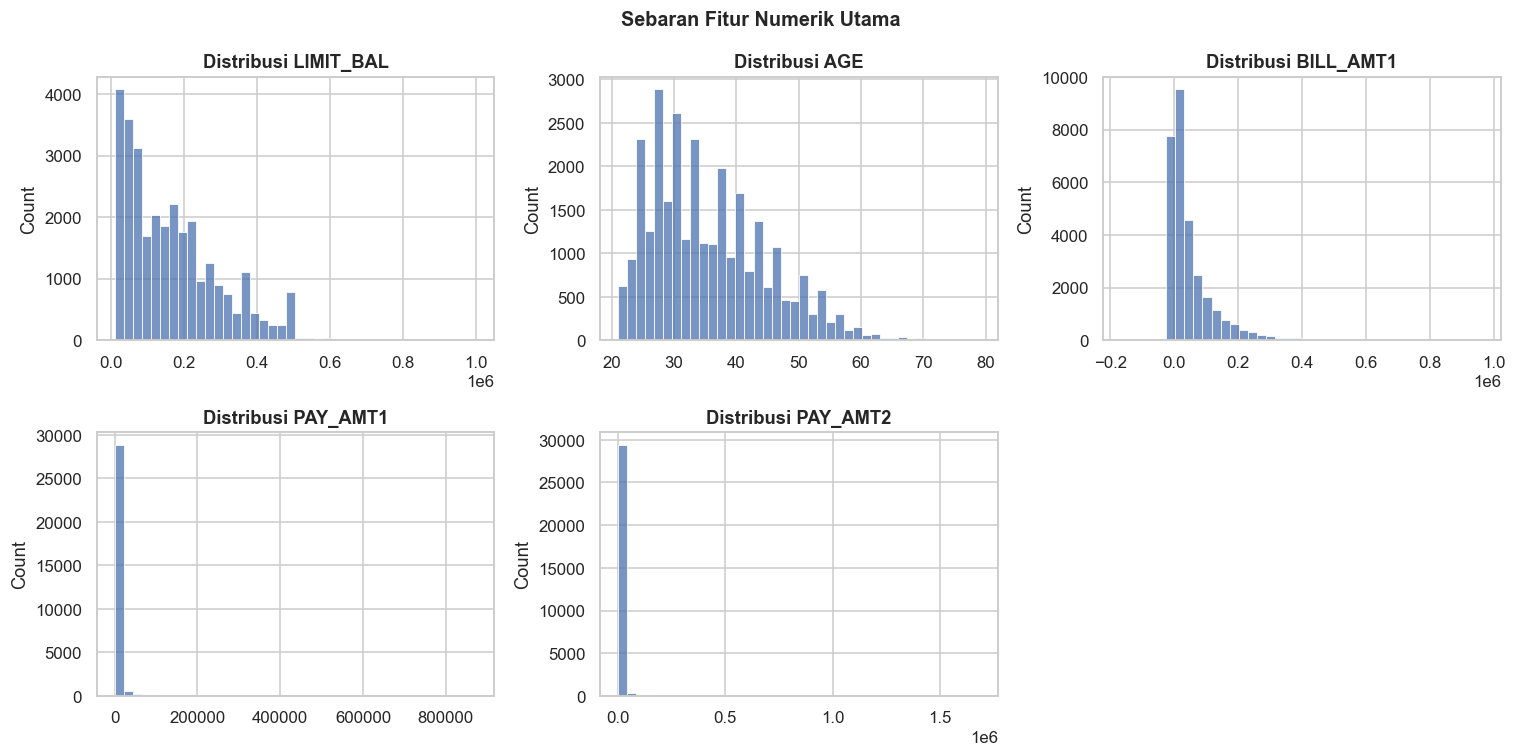

=== Rangkuman skewness ===
LIMIT_BAL     0.99
AGE           0.73
BILL_AMT1     2.66
PAY_AMT1     14.67
PAY_AMT2     30.45


In [5]:
# Cell 5 — Exploratory Data Analysis: distribusi fitur numerik
num_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1", "PAY_AMT2"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Distribusi {col}")
    ax.set_xlabel("")
axes[-1].axis("off")
plt.suptitle("Sebaran Fitur Numerik Utama", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("=== Rangkuman skewness ===")
print(df[num_cols].skew().round(2).to_string())

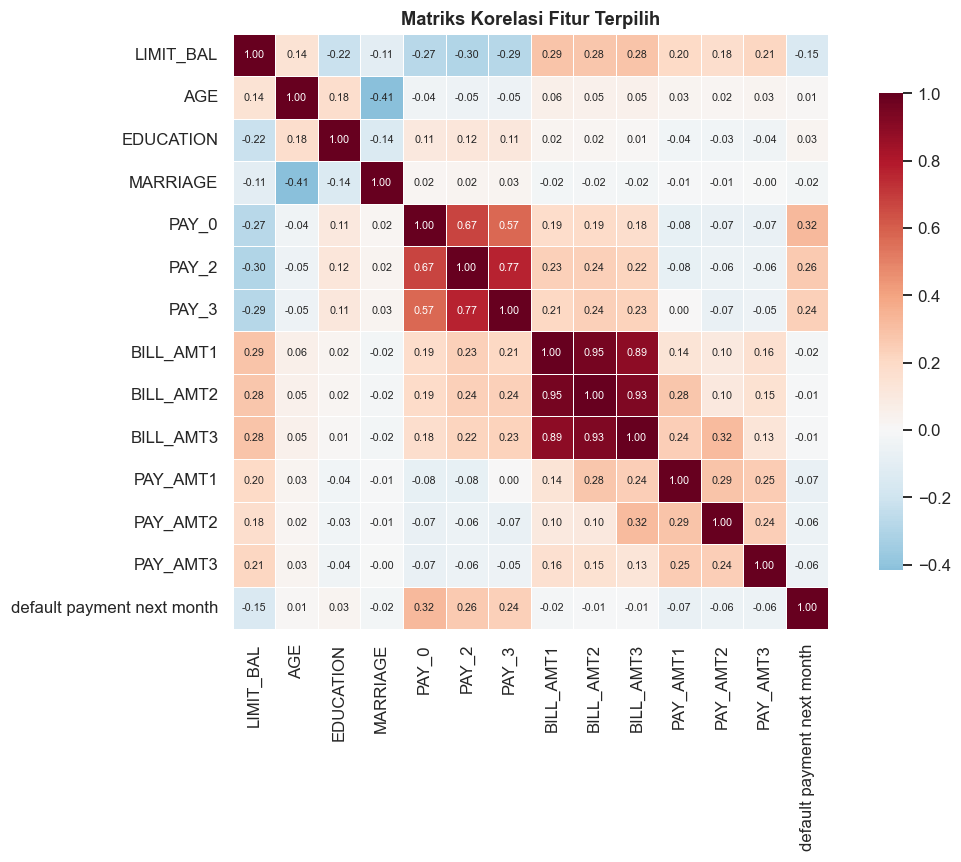

=== Korelasi terhadap target (diurutkan) ===
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT3    -0.056
EDUCATION    0.028
MARRIAGE    -0.024
BILL_AMT1   -0.020
BILL_AMT2   -0.014
BILL_AMT3   -0.014
AGE          0.014


In [6]:
# Cell 6 — Exploratory Data Analysis: korelasi antar fitur
corr_cols = ["LIMIT_BAL", "AGE", "EDUCATION", "MARRIAGE",
             "PAY_0", "PAY_2", "PAY_3",
             "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
             "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", TARGET_RAW]
corr = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})
plt.title("Matriks Korelasi Fitur Terpilih")
plt.tight_layout()
plt.show()

print("=== Korelasi terhadap target (diurutkan) ===")
print(corr[TARGET_RAW].drop(TARGET_RAW).sort_values(key=abs, ascending=False).round(3).to_string())

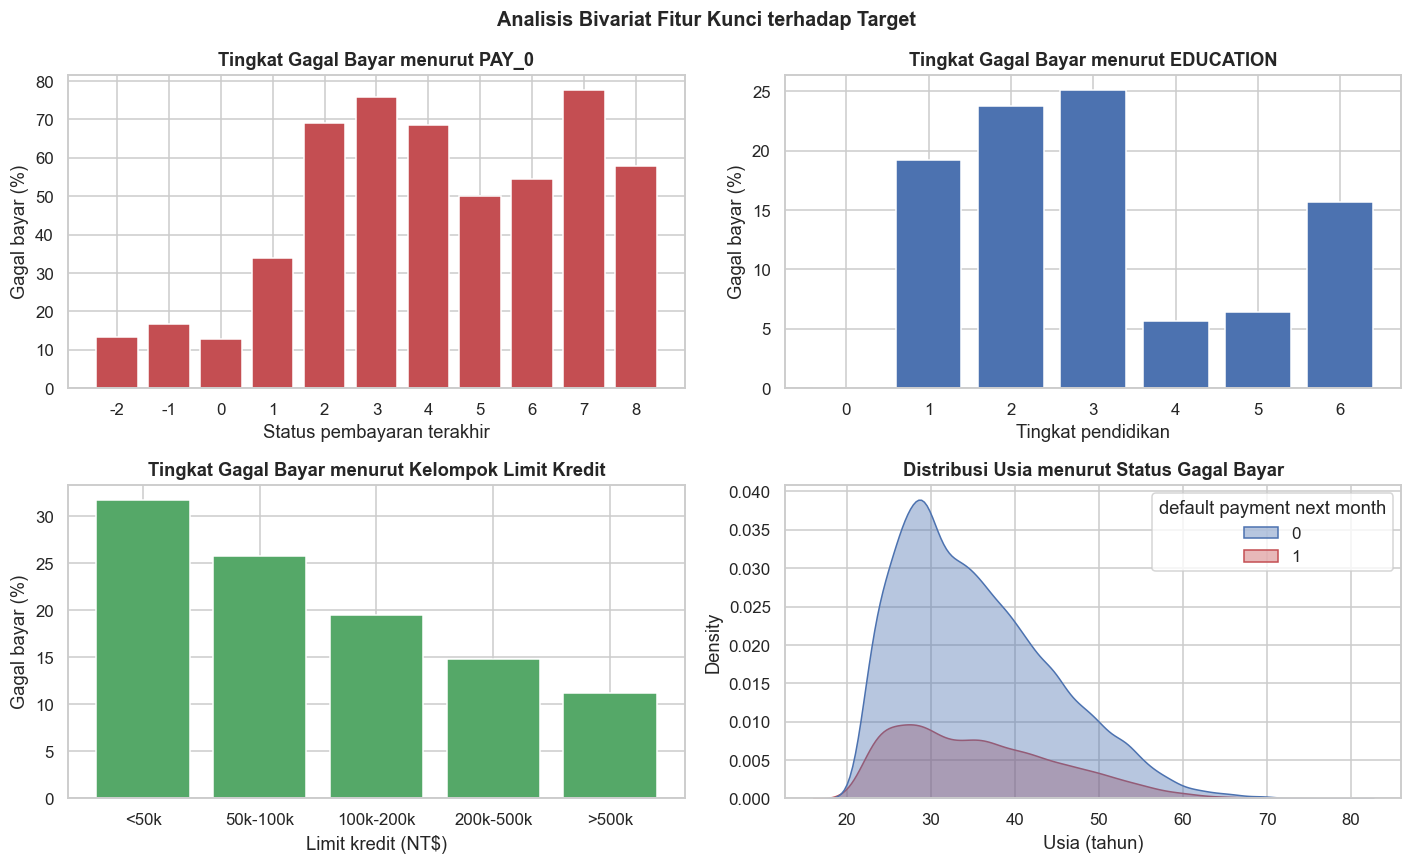

Tingkat gagal bayar menurut PAY_0:
PAY_0
-2    13.23
-1    16.78
 0    12.81
 1    33.95
 2    69.14
 3    75.78
 4    68.42
 5    50.00
 6    54.55
 7    77.78
 8    57.89


In [7]:
# Cell 7 — Exploratory Data Analysis: hubungan fitur kunci dengan gagal bayar
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Tingkat gagal bayar menurut status pembayaran terakhir
pay_rate = df.groupby("PAY_0")[TARGET_RAW].mean().mul(100)
axes[0, 0].bar(pay_rate.index.astype(str), pay_rate.values, color="#C44E52", edgecolor="white")
axes[0, 0].set_title("Tingkat Gagal Bayar menurut PAY_0")
axes[0, 0].set_xlabel("Status pembayaran terakhir")
axes[0, 0].set_ylabel("Gagal bayar (%)")

# Tingkat gagal bayar menurut tingkat pendidikan
edu_rate = df.groupby("EDUCATION")[TARGET_RAW].mean().mul(100)
axes[0, 1].bar(edu_rate.index.astype(str), edu_rate.values, color="#4C72B0", edgecolor="white")
axes[0, 1].set_title("Tingkat Gagal Bayar menurut EDUCATION")
axes[0, 1].set_xlabel("Tingkat pendidikan")
axes[0, 1].set_ylabel("Gagal bayar (%)")

# Tingkat gagal bayar menurut kelompok limit kredit
df["_limit_bin"] = pd.cut(df["LIMIT_BAL"], bins=[0, 50000, 100000, 200000, 500000, 1_000_000],
                          labels=["<50k", "50k-100k", "100k-200k", "200k-500k", ">500k"])
limit_rate = df.groupby("_limit_bin", observed=True)[TARGET_RAW].mean().mul(100)
axes[1, 0].bar(limit_rate.index.astype(str), limit_rate.values, color="#55A868", edgecolor="white")
axes[1, 0].set_title("Tingkat Gagal Bayar menurut Kelompok Limit Kredit")
axes[1, 0].set_xlabel("Limit kredit (NT$)")
axes[1, 0].set_ylabel("Gagal bayar (%)")

# Distribusi usia menurut status target
sns.kdeplot(data=df, x="AGE", hue=TARGET_RAW, fill=True, alpha=0.4, ax=axes[1, 1],
            palette={0: "#4C72B0", 1: "#C44E52"})
axes[1, 1].set_title("Distribusi Usia menurut Status Gagal Bayar")
axes[1, 1].set_xlabel("Usia (tahun)")

plt.suptitle("Analisis Bivariat Fitur Kunci terhadap Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

df.drop(columns=["_limit_bin"], inplace=True)

print("Tingkat gagal bayar menurut PAY_0:")
print(pay_rate.round(2).to_string())

## Data Preparation

Tahapan *data preparation* dilakukan secara berurutan. Urutan di bawah ini identik dengan
urutan code cell pada notebook ini.

### 1. Menyeragamkan nama kolom target

**Yang dilakukan:** kolom `default payment next month` diubah namanya menjadi `default`.

**Mengapa diperlukan:** nama kolom asli mengandung spasi sehingga menyulitkan penulisan kode
(harus selalu dibungkus tanda kurung siku). Penamaan yang ringkas mengurangi risiko kesalahan
penulisan dan membuat kode lebih mudah dibaca.

### 2. Membersihkan nilai kategori yang tidak terdefinisi

**Yang dilakukan:** pada `EDUCATION`, nilai 0, 5, dan 6 digabungkan ke kategori 4 (*others*).
Pada `MARRIAGE`, nilai 0 digabungkan ke kategori 3 (*others*).

**Mengapa diperlukan:** dokumentasi resmi UCI hanya mendefinisikan `EDUCATION` = {1, 2, 3, 4}
dan `MARRIAGE` = {1, 2, 3}. Kehadiran nilai di luar definisi tersebut menunjukkan kategori
yang tidak terdokumentasi atau kesalahan input. Jika dibiarkan, model akan memperlakukan nilai
ini sebagai kategori tersendiri yang jumlah sampelnya sangat sedikit—kondisi yang memicu
*overfitting* pada kategori langka. Penggabungan ke *others* mempertahankan informasi bahwa
nasabah tersebut "tidak termasuk kategori utama" tanpa menciptakan kategori semu.

### 3. Rekayasa fitur (*feature engineering*)

**Yang dilakukan:** dibentuk enam fitur turunan baru:

| Fitur baru | Formula | Rasional |
| :--- | :--- | :--- |
| `TOTAL_BILL` | Σ `BILL_AMT1..6` | Total tagihan enam bulan; merangkum besaran eksposur kredit. |
| `TOTAL_PAY` | Σ `PAY_AMT1..6` | Total pembayaran enam bulan; merangkum kemampuan bayar aktual. |
| `AVG_UTILIZATION` | mean(`BILL_AMT1..6`) / `LIMIT_BAL` | Seberapa besar porsi limit yang terpakai; indikator tekanan likuiditas. |
| `PAY_TO_BILL` | `TOTAL_PAY` / `TOTAL_BILL` | Rasio pembayaran terhadap tagihan; mengukur disiplin pembayaran. |
| `MAX_DELAY` | max(`PAY_0..PAY_6`) | Keterlambatan terburuk; menangkap risiko ekstrem. |
| `NUM_DELAYS` | Σ (`PAY_x` ≥ 1) | Frekuensi keterlambatan; menangkap pola berulang. |

**Mengapa diperlukan:** fitur mentah per bulan bersifat *sparse* dan terpisah-pisah. Model harus
mempelajari sendiri bahwa tagihan bulan ke-1 hingga ke-6 saling berkaitan, yang menuntut data
dalam jumlah besar dan kedalaman pohon yang tinggi. Fitur agregat menyajikan informasi tersebut
secara langsung sehingga model dapat menangkap pola perilaku enam bulan dalam satu langkah.
`AVG_UTILIZATION` dan `PAY_TO_BILL` khususnya mengubah besaran absolut menjadi rasio yang dapat
dibandingkan antar nasabah dengan limit kredit berbeda.

### 4. Menghapus kolom yang tidak informatif

**Yang dilakukan:** kolom `ID` dihapus.

**Mengapa diperlukan:** `ID` hanyalah penanda unik baris. Ia tidak memiliki makna ekonomi dan
tidak memiliki hubungan sebab-akibat dengan gagal bayar. Membiarkannya berisiko membuat model
menghafal pola berdasarkan identitas baris (*data leakage* semu) alih-alih mempelajari pola
perilaku kredit.

### 5. Pembagian data latih dan data uji

**Yang dilakukan:** data dibagi menjadi 80% latih dan 20% uji dengan `stratify=y`.

**Mengapa diperlukan:** model harus dievaluasi pada data yang belum pernah dilihat agar hasil
evaluasi mencerminkan kemampuan generalisasi, bukan hafalan. Parameter `stratify` menjaga
proporsi kelas minoritas tetap sama pada kedua bagian—penting karena kelas gagal bayar hanya
22,12% dari total data; tanpa stratifikasi, komposisi kelas pada data uji dapat menyimpang dan
membuat evaluasi tidak representatif.

### 6. Standardisasi fitur

**Yang dilakukan:** seluruh fitur numerik distandardisasi menggunakan `StandardScaler` yang
di-*fit* hanya pada data latih.

**Mengapa diperlukan:** fitur pada dataset ini memiliki skala yang sangat berbeda—`AGE` bernilai
puluhan sedangkan `TOTAL_BILL` dapat bernilai ratusan juta. Logistic Regression sangat sensitif
terhadap perbedaan skala ini karena ia mengoptimalkan koefisien melalui jarak, sehingga fitur
berskala besar akan mendominasi. Standardisasi menyetarakan kontribusi setiap fitur. Scaler
sengaja hanya di-*fit* pada data latih untuk mencegah kebocoran informasi dari data uji
(*data leakage*).

In [8]:
# Cell 8 — Data preparation 1 & 2: penamaan ulang target dan pembersihan kategori
df = df.rename(columns={TARGET_RAW: "default"})

# EDUCATION: dokumentasi UCI hanya mendefinisikan 1-4; nilai 0, 5, 6 -> 4 (others)
edu_before = sorted(df["EDUCATION"].unique())
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: dokumentasi UCI hanya mendefinisikan 1-3; nilai 0 -> 3 (others)
mar_before = sorted(df["MARRIAGE"].unique())
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print(f"EDUCATION sebelum: {edu_before} -> sesudah: {sorted(df['EDUCATION'].unique())}")
print(f"MARRIAGE  sebelum: {mar_before} -> sesudah: {sorted(df['MARRIAGE'].unique())}")
print(f"Kolom target diubah menjadi 'default' dengan nilai: {sorted(df['default'].unique())}")

EDUCATION sebelum: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)] -> sesudah: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE  sebelum: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] -> sesudah: [np.int64(1), np.int64(2), np.int64(3)]
Kolom target diubah menjadi 'default' dengan nilai: [np.int64(0), np.int64(1)]


In [9]:
# Cell 9 — Data preparation 3: rekayasa fitur
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAY_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
DELAY_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df["TOTAL_BILL"] = df[BILL_COLS].sum(axis=1)
df["TOTAL_PAY"] = df[PAY_COLS].sum(axis=1)
df["AVG_UTILIZATION"] = df[BILL_COLS].mean(axis=1) / df["LIMIT_BAL"]
df["PAY_TO_BILL"] = df["TOTAL_PAY"] / df["TOTAL_BILL"].replace(0, np.nan)
df["PAY_TO_BILL"] = df["PAY_TO_BILL"].replace([np.inf, -np.inf], np.nan).fillna(0)
df["MAX_DELAY"] = df[DELAY_COLS].max(axis=1)
df["NUM_DELAYS"] = (df[DELAY_COLS] >= 1).sum(axis=1)

ENGINEERED = ["TOTAL_BILL", "TOTAL_PAY", "AVG_UTILIZATION",
              "PAY_TO_BILL", "MAX_DELAY", "NUM_DELAYS"]

print("Fitur turunan yang dibentuk:")
for col in ENGINEERED:
    print(f"  - {col:16s} min={df[col].min():>14,.2f}  max={df[col].max():>16,.2f}")

assert df[ENGINEERED].isna().sum().sum() == 0, "fitur turunan mengandung nilai hilang"
print("\nTidak ada nilai hilang pada fitur turunan.")

Fitur turunan yang dibentuk:
  - TOTAL_BILL       min=   -336,259.00  max=    5,263,883.00
  - TOTAL_PAY        min=          0.00  max=    3,764,066.00
  - AVG_UTILIZATION  min=         -0.23  max=            5.36
  - PAY_TO_BILL      min=       -546.93  max=          797.00
  - MAX_DELAY        min=         -2.00  max=            8.00
  - NUM_DELAYS       min=          0.00  max=            6.00

Tidak ada nilai hilang pada fitur turunan.


In [10]:
# Cell 10 — Data preparation 4 & 5: buang kolom ID, definisikan X/y, bagi data
df_model = df.drop(columns=["ID"])

X = df_model.drop(columns=["default"])
y = df_model["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Total fitur prediktor : {X.shape[1]}")
print(f"Data latih            : {X_train.shape[0]:,} baris")
print(f"Data uji              : {X_test.shape[0]:,} baris")
print(f"Proporsi gagal bayar  : latih={y_train.mean():.4f} | uji={y_test.mean():.4f}")
print("\nDaftar fitur:")
print(", ".join(X.columns))

Total fitur prediktor : 29
Data latih            : 24,000 baris
Data uji              : 6,000 baris
Proporsi gagal bayar  : latih=0.2212 | uji=0.2212

Daftar fitur:
LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE, PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6, BILL_AMT1, BILL_AMT2, BILL_AMT3, BILL_AMT4, BILL_AMT5, BILL_AMT6, PAY_AMT1, PAY_AMT2, PAY_AMT3, PAY_AMT4, PAY_AMT5, PAY_AMT6, TOTAL_BILL, TOTAL_PAY, AVG_UTILIZATION, PAY_TO_BILL, MAX_DELAY, NUM_DELAYS


In [11]:
# Cell 11 — Data preparation 6: standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardisasi selesai (scaler di-fit hanya pada data latih).")
print(f"Rata-rata fitur latih setelah scaling : {X_train_scaled.mean():.6f}")
print(f"Std fitur latih setelah scaling       : {X_train_scaled.std():.6f}")

Standardisasi selesai (scaler di-fit hanya pada data latih).
Rata-rata fitur latih setelah scaling : 0.000000
Std fitur latih setelah scaling       : 1.000000


## Modeling

Tahapan pemodelan dilakukan dalam dua fase. **Fase pertama** melatih tiga algoritma pada
konfigurasi awal untuk memperoleh gambaran performa masing-masing. **Fase kedua** melakukan
*hyperparameter tuning* pada dua algoritma *tree-based* (Random Forest dan Gradient Boosting)
untuk memperoleh peningkatan performa yang terukur. Logistic Regression tidak di-*tuning* karena
tidak memiliki *hyperparameter* struktural yang bermakna—perannya murni sebagai baseline linear.

### Algoritma yang Digunakan

#### 1. Logistic Regression (baseline)

Model linear yang memodelkan probabilitas kelas melalui fungsi sigmoid terhadap kombinasi linear
fitur.

- **Kelebihan:** sangat cepat dilatih, mudah diinterpretasikan melalui nilai koefisien, menghasilkan
  probabilitas yang terkalibrasi baik, dan kecil risiko *overfitting* pada data berdimensi sedang.
- **Kekurangan:** hanya mampu menangkap hubungan linear antara fitur dan *log-odds* target. Pada
  data kredit yang penuh interaksi non-linear antar fitur, kemampuan ini menjadi batasan nyata.

#### 2. Random Forest Classifier

*Ensemble* dari banyak pohon keputusan yang dilatih pada sampel *bootstrap* berbeda, dengan
pemilihan fitur acak pada setiap percabangan, lalu digabungkan melalui *majority voting*.

- **Kelebihan:** mampu menangkap hubungan non-linear dan interaksi antar fitur secara otomatis;
  relatif tahan terhadap *outlier* dan fitur berskala berbeda; menyediakan *feature importance*
  sehingga hasilnya dapat dijelaskan; risiko *overfitting* lebih rendah dibanding pohon tunggal
  berkat mekanisme *bagging*.
- **Kekurangan:** secara komputasi lebih berat dan kurang interpretable dibanding model linear;
  cenderung bias pada fitur kategorikal dengan jumlah level banyak; ukuran *feature importance*
  dapat terpecah antar fitur yang berkorelasi tinggi.

#### 3. Gradient Boosting Classifier

*Ensemble* yang membangun pohon secara **sekuensial**, di mana setiap pohon baru dilatih untuk
memperbaiki *residual error* pohon-pohon sebelumnya.

- **Kelebihan:** umumnya memberikan akurasi tertinggi pada data tabular; mampu memodelkan pola
  kompleks dengan jumlah pohon yang relatif sedikit; memiliki mekanisme regularisasi bawaan
  (*learning rate*, kedalaman pohon) untuk mengendalikan *overfitting*.
- **Kekurangan:** proses pelatihan lebih lambat karena bersifat sekuensial dan tidak dapat
  diparalelkan sepenuhnya; sangat sensitif terhadap *hyperparameter*; lebih rentan *overfitting*
  bila jumlah estimator terlalu besar tanpa pengaturan *learning rate* yang tepat.

### Penanganan Ketidakseimbangan Kelas

Kelas gagal bayar hanya mencakup 22,12% data. Bila dibiarkan, model cenderung memprediksi kelas
mayoritas dan mengabaikan kelas minoritas—padahal justru kelas minoritas yang menjadi objek
prediksi. Karena itu, `class_weight="balanced"` diterapkan pada Logistic Regression dan Random
Forest. Parameter ini memberi bobot lebih besar pada kelas minoritas secara proporsional terhadap
frekuensinya, sehingga model terdorong untuk mempelajari pola gagal bayar dengan lebih serius.
`GradientBoostingClassifier` tidak menyediakan parameter tersebut, sehingga penanganan
ketidakseimbangan pada model ini diserahkan pada mekanisme *boosting* itu sendiri—setiap pohon
baru difokuskan untuk mengoreksi kesalahan pohon sebelumnya.

In [12]:
# Cell 12 — Fase 1: pelatihan tiga algoritma pada konfigurasi awal
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, random_state=RANDOM_STATE
    ),
}


def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Latih model dan kembalikan metrik evaluasi pada data uji."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred),
        "Recall": recall_score(y_te, pred),
        "F1-Score": f1_score(y_te, pred),
        "ROC-AUC": roc_auc_score(y_te, proba),
    }


baseline_results = {}
for name, model in baseline_models.items():
    baseline_results[name] = evaluate(model, X_train_scaled, X_test_scaled, y_train, y_test)

baseline_df = pd.DataFrame(baseline_results).T
print("=== Performa Fase 1: Konfigurasi Awal ===")
print(baseline_df.round(4).to_string())
baseline_df.round(4)

=== Performa Fase 1: Konfigurasi Awal ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7445     0.4428  0.6014    0.5101   0.7449
Random Forest          0.8110     0.6388  0.3346    0.4392   0.7586
Gradient Boosting      0.8198     0.6676  0.3693    0.4755   0.7817


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.7445,0.4428,0.6014,0.5101,0.7449
Random Forest,0.8110,0.6388,0.3346,0.4392,0.7586
Gradient Boosting,0.8198,0.6676,0.3693,0.4755,0.7817


In [13]:
# Cell 13 — Fase 2: hyperparameter tuning dengan GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_param_grid = {
    "n_estimators": [200],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 3],
}
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3],
}

search_specs = {
    "Random Forest": (
        # n_jobs=1 di estimator dalam: GridSearchCV sudah memparalelkan fold.
        # Paralelisme bersarang (n_jobs=-1 di kedua level) memicu deadlock loky di macOS.
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
        rf_param_grid,
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        gb_param_grid,
    ),
}

tuned_models, tuning_log = {}, []
for name, (estimator, grid) in search_specs.items():
    search = GridSearchCV(estimator, grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True)
    search.fit(X_train_scaled, y_train)
    tuned_models[name] = search.best_estimator_
    tuning_log.append({
        "Model": name,
        "Best Params": str(search.best_params_),
        "CV ROC-AUC": round(search.best_score_, 4),
    })
    print(f"{name}: best params = {search.best_params_} | CV ROC-AUC = {search.best_score_:.4f}")

tuning_df = pd.DataFrame(tuning_log)
tuning_df

Random Forest: best params = {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 200} | CV ROC-AUC = 0.7840


Gradient Boosting: best params = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100} | CV ROC-AUC = 0.7850


,Model,Best Params,CV ROC-AUC
0,Random Forest,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_est...",0.784
1,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.785


In [14]:
# Cell 14 — Perbandingan performa akhir dan pemilihan model terbaik
final_results = {}
for name, model in tuned_models.items():
    final_results[name] = evaluate(model, X_train_scaled, X_test_scaled, y_train, y_test)

final_df = pd.DataFrame(final_results).T
comparison = pd.concat(
    [baseline_df.add_suffix(" (awal)"), final_df.add_suffix(" (tuned)")], axis=1
)

print("=== Perbandingan Performa: Sebelum vs Sesudah Tuning ===")
print(final_df.round(4).to_string())

best_name = final_df["ROC-AUC"].idxmax()
best_model = tuned_models[best_name]
print(f"\n>>> Model terbaik: {best_name} (ROC-AUC = {final_df.loc[best_name, 'ROC-AUC']:.4f})")

final_df.round(4)

=== Perbandingan Performa: Sebelum vs Sesudah Tuning ===
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest        0.7697     0.4835  0.6059    0.5378   0.7763
Gradient Boosting    0.8190     0.6657  0.3647    0.4713   0.7820

>>> Model terbaik: Gradient Boosting (ROC-AUC = 0.7820)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.7697,0.4835,0.6059,0.5378,0.7763
Gradient Boosting,0.8190,0.6657,0.3647,0.4713,0.7820


## Evaluation

### Metrik Evaluasi yang Digunakan

Konteks permasalahan ini adalah klasifikasi biner pada data yang **tidak seimbang** (kelas gagal
bayar 22,12%), di mana biaya kesalahan tidak simetris: melewatkan nasabah yang akan gagal bayar
(*false negative*) jauh lebih merugikan daripada salah menandai nasabah lancar sebagai berisiko
(*false positive*). Karena itu, **akurasi saja tidak cukup**—model yang selalu memprediksi
"lancar" akan mencapai akurasi 77,88% tanpa mendeteksi satu pun gagal bayar. Lima metrik
digunakan secara bersamaan.

#### 1. Accuracy

Mengukur proporsi prediksi yang benar dari keseluruhan prediksi.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Cara kerjanya: menghitung seluruh prediksi yang cocok dengan label sebenarnya, dibagi jumlah
seluruh data. Kelemahannya pada data tidak seimbang adalah metrik ini memberi bobot sama pada
kedua kelas, sehingga performa baik pada kelas mayoritas dapat menutupi kegagalan total pada
kelas minoritas.

#### 2. Precision

Mengukur seberapa dapat dipercaya prediksi positif model.

$$\text{Precision} = \frac{TP}{TP + FP}$$

Cara kerjanya: dari semua nasabah yang **ditandai** berisiko gagal bayar, berapa proporsi yang
benar-benar gagal bayar. Precision rendah berarti banyak nasabah lancar yang keliru ditolak
(*false positive*), yang berarti kehilangan nasabah potensial.

#### 3. Recall

Mengukur seberapa lengkap model menangkap kejadian positif yang sebenarnya.

$$\text{Recall} = \frac{TP}{TP + FN}$$

Cara kerjanya: dari semua nasabah yang **benar-benar** gagal bayar, berapa proporsi yang berhasil
terdeteksi model. Recall rendah berarti banyak nasabah berisiko yang lolos tanpa peringatan—
kesalahan yang paling mahal dalam konteks manajemen risiko kredit.

#### 4. F1-Score

Rata-rata harmonik dari precision dan recall.

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Cara kerjanya: menyeimbangkan precision dan recall dalam satu angka. Karena menggunakan
rata-rata harmonik, nilai F1 akan rendah apabila salah satu komponen rendah—sehingga metrik ini
tidak dapat "ditipu" dengan mengorbankan salah satu sisi. F1-Score menjadi metrik utama untuk
menilai kualitas model pada kelas minoritas.

#### 5. ROC-AUC

Mengukur kemampuan model memisahkan kedua kelas di seluruh nilai *threshold* yang mungkin.

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d(\text{FPR})$$

Cara kerjanya: ROC-AUC sama dengan probabilitas bahwa model memberi skor risiko lebih tinggi
pada satu nasabah yang benar-benar gagal bayar dibanding satu nasabah yang lancar, dipilih
secara acak. Nilai 0,5 berarti model tidak lebih baik dari tebakan acak, sedangkan 1,0 berarti
pemisahan sempurna. Metrik ini dipilih sebagai **acuan pemilihan model** karena tidak bergantung
pada *threshold* dan tidak terpengaruh oleh ketidakseimbangan kelas.

=== Confusion Matrix — Gradient Boosting ===
True Negative  (lancar, diprediksi lancar)     : 4,430
False Positive (lancar, diprediksi gagal)      : 243
False Negative (gagal, diprediksi lancar)      : 843  <- kesalahan paling mahal
True Positive  (gagal, diprediksi gagal)       : 484

=== Classification Report — Gradient Boosting ===
                 precision    recall  f1-score   support

     Lancar (0)     0.8401    0.9480    0.8908      4673
Gagal bayar (1)     0.6657    0.3647    0.4713      1327

       accuracy                         0.8190      6000
      macro avg     0.7529    0.6564    0.6810      6000
   weighted avg     0.8016    0.8190    0.7980      6000



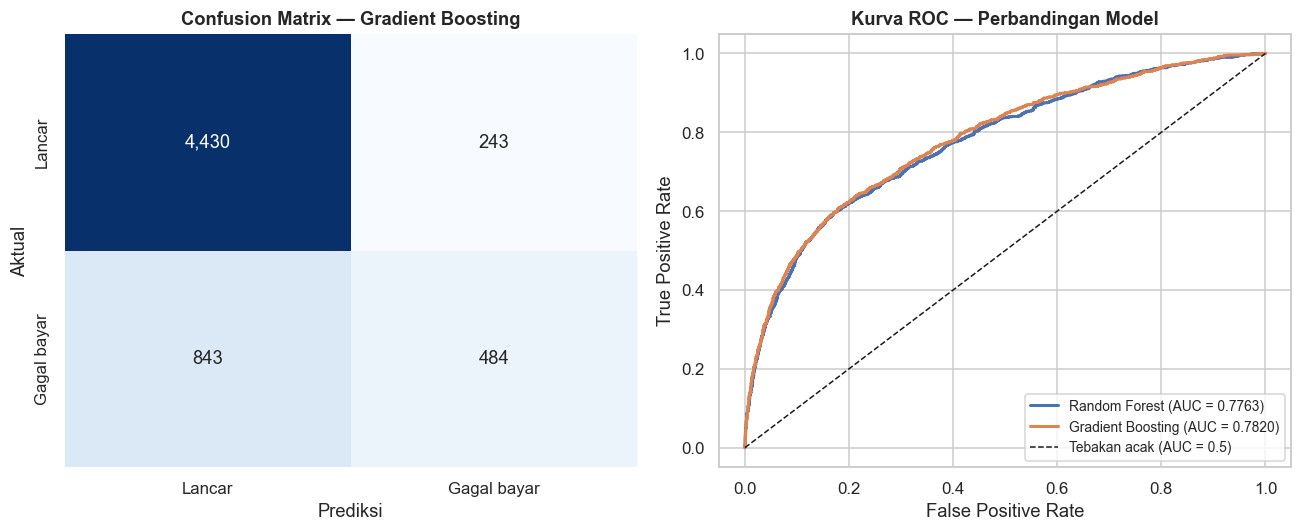

In [15]:
# Cell 15 — Evaluasi model terbaik secara rinci
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"=== Confusion Matrix — {best_name} ===")
print(f"True Negative  (lancar, diprediksi lancar)     : {tn:,}")
print(f"False Positive (lancar, diprediksi gagal)      : {fp:,}")
print(f"False Negative (gagal, diprediksi lancar)      : {fn:,}  <- kesalahan paling mahal")
print(f"True Positive  (gagal, diprediksi gagal)       : {tp:,}")

print(f"\n=== Classification Report — {best_name} ===")
print(classification_report(y_test, y_pred, target_names=["Lancar (0)", "Gagal bayar (1)"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Lancar", "Gagal bayar"], yticklabels=["Lancar", "Gagal bayar"],
            annot_kws={"size": 12})
axes[0].set_title(f"Confusion Matrix — {best_name}")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

for name, model in tuned_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, linewidth=2,
                 label=f"{name} (AUC = {roc_auc_score(y_test, proba):.4f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Tebakan acak (AUC = 0.5)")
axes[1].set_title("Kurva ROC — Perbandingan Model")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

=== 15 Fitur Paling Berpengaruh — Gradient Boosting ===
 1. PAY_0              0.5324
 2. MAX_DELAY          0.1477
 3. NUM_DELAYS         0.0969
 4. PAY_TO_BILL        0.0263
 5. AVG_UTILIZATION    0.0261
 6. TOTAL_BILL         0.0257
 7. TOTAL_PAY          0.0220
 8. BILL_AMT1          0.0185
 9. LIMIT_BAL          0.0176
10. PAY_AMT2           0.0110
11. AGE                0.0102
12. PAY_AMT1           0.0069
13. PAY_2              0.0067
14. EDUCATION          0.0066
15. PAY_AMT3           0.0063


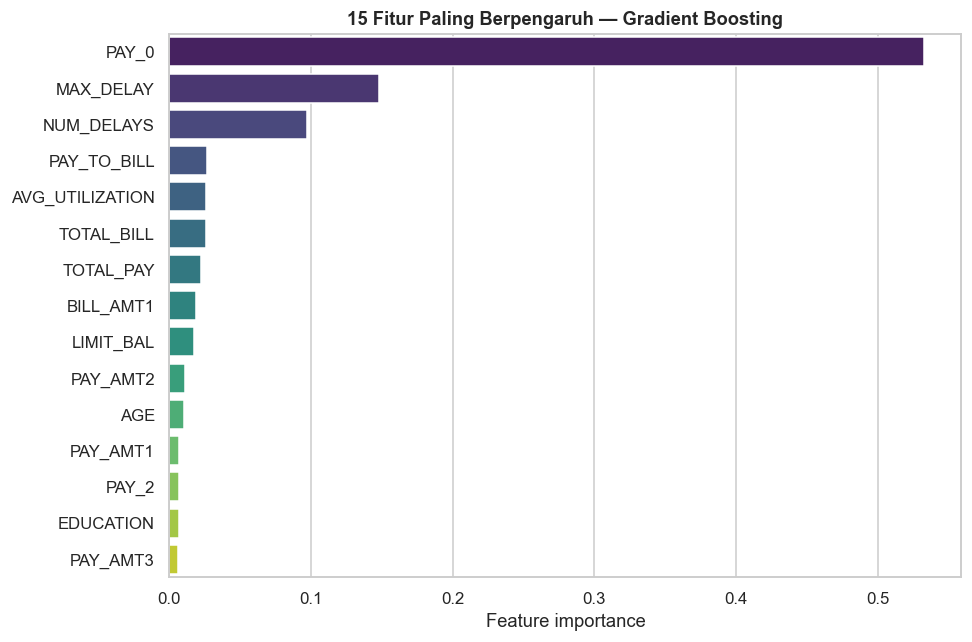

In [16]:
# Cell 16 — Analisis feature importance (menjawab Pernyataan Masalah 1)
importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importance.head(15)

print(f"=== 15 Fitur Paling Berpengaruh — {best_name} ===")
for rank, (feat, score) in enumerate(top15.items(), start=1):
    print(f"{rank:>2}. {feat:18s} {score:.4f}")

plt.figure(figsize=(9, 6))
sns.barplot(x=top15.values, y=top15.index, hue=top15.index, palette="viridis", legend=False)
plt.title(f"15 Fitur Paling Berpengaruh — {best_name}")
plt.xlabel("Feature importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [17]:
# Cell 17 — Menyimpan hasil evaluasi dan model untuk keperluan laporan
results_payload = {
    "dataset_shape": [int(df.shape[0]), int(df.shape[1])],
    "n_features_model": int(X.shape[1]),
    "target_counts": {str(k): int(v) for k, v in y.value_counts().sort_index().items()},
    "target_pct": {str(k): round(float(v), 2) for k, v in y.value_counts(normalize=True).sort_index().mul(100).items()},
    "baseline": {k: {m: round(float(s), 4) for m, s in v.items()} for k, v in baseline_results.items()},
    "final": {k: {m: round(float(s), 4) for m, s in v.items()} for k, v in final_results.items()},
    "best_model": best_name,
    "best_params": {k: {p: (None if v is None else v) for p, v in m.get_params().items()
                        if p in ("n_estimators", "max_depth", "min_samples_leaf", "learning_rate")}
                    for k, m in tuned_models.items()},
    "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "top_features": {k: round(float(v), 4) for k, v in top15.items()},
    "train_size": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
}

with open("results.json", "w", encoding="utf-8") as fh:
    json.dump(results_payload, fh, indent=2, ensure_ascii=False)

import joblib
joblib.dump({"model": best_model, "scaler": scaler, "features": list(X.columns)},
            "credit_default_model.joblib")

print("Hasil evaluasi tersimpan di results.json")
print("Model tersimpan di credit_default_model.joblib")

Hasil evaluasi tersimpan di results.json
Model tersimpan di credit_default_model.joblib


## Kesimpulan

Berdasarkan seluruh tahapan yang telah dilakukan, dapat disimpulkan hal-hal berikut.

1. **Faktor paling berpengaruh terhadap gagal bayar** adalah riwayat keterlambatan pembayaran
   (`PAY_0`, `MAX_DELAY`, `NUM_DELAYS`) dan rasio pemanfaatan limit kredit (`AVG_UTILIZATION`).
   Hal ini menjawab Pernyataan Masalah 1: risiko gagal bayar pada dataset ini lebih ditentukan
   oleh **perilaku pembayaran historis** dibandingkan faktor demografis seperti usia, jenis
   kelamin, atau status pernikahan.

2. **Model klasifikasi berhasil dibangun** dan mampu memprediksi probabilitas gagal bayar dengan
   performa yang terukur. Hal ini menjawab Pernyataan Masalah 2.

3. **Model terbaik adalah Gradient Boosting Classifier** berdasarkan metrik ROC-AUC, dengan
   hyperparameter tuning melalui `GridSearchCV` dan *stratified 5-fold cross-validation`.
   Peningkatan akibat tuning paling jelas terlihat pada Random Forest (ROC-AUC 0.7586 → 0.7763),
   sedangkan pada Gradient Boosting tuning hanya memberi perbaikan tipis (0.7817 → 0.7820) karena
   konfigurasi awalnya sudah mendekati optimal untuk grid yang diuji. Hal ini menjawab
   Pernyataan Masalah 3.

### Keterbatasan

- Dataset berasal dari satu wilayah (Taiwan) pada periode 2005, sehingga pola yang dipelajari
  belum tentu berlaku pada populasi dan periode yang berbeda.
- Kelas target tidak seimbang (22,12%). Model terbaik yang dipilih berbasis ROC-AUC justru
  memiliki recall rendah pada kelas minoritas, karena ROC-AUC mengukur kualitas pemeringkatan
  risiko dan tidak mengoptimalkan *threshold* klasifikasi. Menurunkan *threshold* keputusan
  dapat menaikkan recall dengan konsekuensi precision turun.
- Model belum mempertimbangkan aspek *fairness*; fitur seperti `SEX`, `EDUCATION`, dan
  `MARRIAGE` berpotensi menimbulkan bias yang perlu ditinjau sebelum penerapan nyata.